In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv
/kaggle/input/datasets/harshvishwakarma23/recipe-updates/protocol_manual_classification_updated.csv


In [2]:
!pip install -q sentence-transformers umap-learn


In [3]:
# =========================
# BioBERT Clustering Pipeline (Kaggle-Ready)
# =========================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
REMARK_CANDIDATES = ["remark_manual", "remark_auto"]
NUM_CLUSTERS = 30

BATCH_SIZE = 32 if torch.cuda.is_available() else 8

# -------------------------
# Load & standardize data
# -------------------------
df = pd.read_csv(DATA_FILE)
df = df.fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)

df["Word"] = df[LABEL_COL].astype(str) if LABEL_COL in df.columns else df.index.astype(str)
remark_col = next((c for c in REMARK_CANDIDATES if c in df.columns), None)
df["REMARK"] = df[remark_col].astype(str) if remark_col else ""

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# -------------------------
# Helper functions
# -------------------------
def try_sentence_transformer(candidates, texts, batch_size):
    for name in candidates:
        try:
            print(f"Trying SentenceTransformer: {name}")
            model = SentenceTransformer(name, device=str(DEVICE))
            emb = model.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True
            )
            return emb.astype(np.float32), name
        except Exception as e:
            print(f"Failed {name}: {e}")
    return None, None


def hf_mean_pool_embeddings(model_name, texts, batch_size, max_length=512):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()

    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="BioBERT embedding"):
            batch = texts[i:i + batch_size]
            enc = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            output = model(**enc)

            last_hidden = output.last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
            embeddings.append(pooled.cpu().numpy())

    return np.vstack(embeddings).astype(np.float32)

# -------------------------
# Generate embeddings
# -------------------------
texts = df[TEXT_COL].tolist()

st_candidates = [
    "pritamdeka/biobert-base-cased-sentence-transformer"
]

embeddings, model_used = try_sentence_transformer(
    st_candidates, texts, BATCH_SIZE
)

if embeddings is None:
    HF_BIOBERT = "dmis-lab/biobert-base-cased-v1.1"
    print("Using HF BioBERT fallback:", HF_BIOBERT)
    embeddings = hf_mean_pool_embeddings(
        HF_BIOBERT, texts, batch_size=BATCH_SIZE // 2
    )
    model_used = HF_BIOBERT

np.save("biobert_embeddings.npy", embeddings)
print("Saved embeddings")
print("Model used:", model_used)

# -------------------------
# Cosine similarity
# -------------------------
print("Computing cosine similarity...")
sim_matrix = cosine_similarity(embeddings)

pd.DataFrame(
    sim_matrix,
    index=df["Word"],
    columns=df["Word"]
).to_csv("biobert_cosine_similarity_matrix.csv")

# -------------------------
# Hierarchical clustering
# -------------------------
distance = 1.0 - sim_matrix
condensed = squareform(distance, checks=False)
Z = linkage(condensed, method="average")

plt.figure(figsize=(18, 8))
dendrogram(
    Z,
    labels=df["Word"].values,
    leaf_rotation=90,
    leaf_font_size=6
)
plt.title("Hierarchical Clustering (BioBERT)")
plt.tight_layout()
plt.savefig("biobert_dendrogram.png", dpi=300)
plt.close()

# -------------------------
# Cut clusters
# -------------------------
df["biobert_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_biobert_clusters.csv", index=False)

# -------------------------
# UMAP visualization
# -------------------------
print("Running UMAP...")
umap_model = umap.UMAP(
    n_components=2,
    random_state=SEED,
    n_neighbors=15,
    min_dist=0.1
)
umap_emb = umap_model.fit_transform(embeddings)

df["umap_x"] = umap_emb[:, 0]
df["umap_y"] = umap_emb[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x="umap_x",
    y="umap_y",
    hue="biobert_cluster",
    data=df,
    palette="tab20",
    legend=False
)
plt.title("UMAP Projection (BioBERT)")
plt.tight_layout()
plt.savefig("biobert_umap.png", dpi=300)
plt.close()

# -------------------------
# Silhouette score
# -------------------------
if df["biobert_cluster"].nunique() > 1:
    sil = silhouette_score(
        embeddings,
        df["biobert_cluster"],
        metric="cosine"
    )
    print("Silhouette score:", sil)

# -------------------------
# Save per-cluster files
# -------------------------
os.makedirs("biobert_clusters", exist_ok=True)

for cid, group in df.groupby("biobert_cluster"):
    group.to_csv(f"biobert_clusters/cluster_{cid}.csv", index=False)

print("\nPipeline completed successfully ✅")


2026-04-09 17:11:31.880307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775754692.080558      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775754692.136179      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775754692.613430      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775754692.613469      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775754692.613472      55 computation_placer.cc:177] computation placer alr

Device: cuda
Rows: 270
Columns: ['word', 'remark_manual', 'remark_auto', 'definition_source_1', 'definition_source_2', 'definition_source_3', 'food_example', 'unnamed: 6', 'merged_text', 'tfidf_cluster', 'remark_auto_aligned', 'alignment_score', 'Word', 'REMARK']
Trying SentenceTransformer: pritamdeka/biobert-base-cased-sentence-transformer
Failed pritamdeka/biobert-base-cased-sentence-transformer: pritamdeka/biobert-base-cased-sentence-transformer is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
Using HF BioBERT fallback: dmis-lab/biobert-base-cased-v1.1


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]


BioBERT embedding: 100%|██████████| 17/17 [00:01<00:00, 15.95it/s]


Saved embeddings
Model used: dmis-lab/biobert-base-cased-v1.1
Computing cosine similarity...
Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette score: 0.09323319

Pipeline completed successfully ✅


In [4]:
# =========================
# PubMedBERT Clustering Pipeline (Kaggle-Ready)
# =========================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
BATCH_SIZE = 16

MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)
df["Word"] = df[LABEL_COL].astype(str)

# -------------------------
# Embeddings
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

texts = df[TEXT_COL].tolist()
embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="PubMedBERT embedding"):
        batch = texts[i:i+BATCH_SIZE]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=512, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**enc)

        last_hidden = out.last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        embeddings.append(pooled.cpu().numpy())

embeddings = np.vstack(embeddings).astype(np.float32)
np.save("pubmedbert_embeddings.npy", embeddings)

# -------------------------
# Cosine similarity
# -------------------------
sim = cosine_similarity(embeddings)
pd.DataFrame(sim, index=df["Word"], columns=df["Word"]) \
  .to_csv("pubmedbert_cosine_similarity.csv")

# -------------------------
# Hierarchical clustering
# -------------------------
Z = linkage(squareform(1 - sim, checks=False), method="average")

plt.figure(figsize=(18,8))
dendrogram(Z, labels=df["Word"].values, leaf_rotation=90, leaf_font_size=6)
plt.title("Hierarchical Clustering (PubMedBERT)")
plt.tight_layout()
plt.savefig("pubmedbert_dendrogram.png", dpi=300)
plt.close()

df["pubmedbert_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_pubmedbert_clusters.csv", index=False)

# -------------------------
# UMAP
# -------------------------
um = umap.UMAP(n_components=2, random_state=SEED)
proj = um.fit_transform(embeddings)

df["umap_x"], df["umap_y"] = proj[:,0], proj[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x="umap_x", y="umap_y",
                hue="pubmedbert_cluster", data=df,
                palette="tab20", legend=False)
plt.title("UMAP (PubMedBERT)")
plt.tight_layout()
plt.savefig("pubmedbert_umap.png", dpi=300)
plt.close()

# -------------------------
# Silhouette
# -------------------------
print("Silhouette:",
      silhouette_score(embeddings, df["pubmedbert_cluster"], metric="cosine"))

# -------------------------
# Save clusters
# -------------------------
os.makedirs("pubmedbert_clusters", exist_ok=True)
for cid, g in df.groupby("pubmedbert_cluster"):
    g.to_csv(f"pubmedbert_clusters/cluster_{cid}.csv", index=False)

print("✅ PubMedBERT pipeline completed")


Device: cuda


tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

PubMedBERT embedding: 100%|██████████| 17/17 [00:00<00:00, 45.45it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.021183183
✅ PubMedBERT pipeline completed


In [5]:
# =========================
# Doc2Vec Clustering Pipeline
# =========================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Config
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
SEED = 42

# -------------------------
# Load
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df["Word"] = df[LABEL_COL].astype(str)

documents = [
    TaggedDocument(simple_preprocess(text), [i])
    for i, text in enumerate(df[TEXT_COL])
]

# -------------------------
# Train Doc2Vec
# -------------------------
model = Doc2Vec(
    vector_size=300,
    window=8,
    min_count=2,
    workers=4,
    epochs=40,
    seed=SEED
)

model.build_vocab(documents)
model.train(documents,
            total_examples=model.corpus_count,
            epochs=model.epochs)

embeddings = np.array(
    [model.dv[i] for i in range(len(documents))],
    dtype=np.float32
)

np.save("doc2vec_embeddings.npy", embeddings)

# -------------------------
# Clustering
# -------------------------
sim = cosine_similarity(embeddings)
Z = linkage(squareform(1 - sim, checks=False), method="average")

plt.figure(figsize=(18,8))
dendrogram(Z, labels=df["Word"].values, leaf_rotation=90, leaf_font_size=6)
plt.title("Hierarchical Clustering (Doc2Vec)")
plt.tight_layout()
plt.savefig("doc2vec_dendrogram.png", dpi=300)
plt.close()

df["doc2vec_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_doc2vec_clusters.csv", index=False)

# -------------------------
# UMAP
# -------------------------
proj = umap.UMAP(random_state=SEED).fit_transform(embeddings)
df["umap_x"], df["umap_y"] = proj[:,0], proj[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x="umap_x", y="umap_y",
                hue="doc2vec_cluster", data=df,
                palette="tab20", legend=False)
plt.title("UMAP (Doc2Vec)")
plt.tight_layout()
plt.savefig("doc2vec_umap.png", dpi=300)
plt.close()

print("Silhouette:",
      silhouette_score(embeddings, df["doc2vec_cluster"], metric="cosine"))

os.makedirs("doc2vec_clusters", exist_ok=True)
for cid, g in df.groupby("doc2vec_cluster"):
    g.to_csv(f"doc2vec_clusters/cluster_{cid}.csv", index=False)

print("✅ Doc2Vec pipeline completed")


/usr/local/lib/python3.12/dist-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.63328
✅ Doc2Vec pipeline completed


In [6]:
# =========================
# FoodBERT & CookBERT Clustering Pipeline
# =========================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
BATCH_SIZE = 16

# -------------------------
# Models
# -------------------------
# Public alternatives:
FOODBERT_MODEL = "alexdseo/RecipeBERT"   # Food-domain BERT
COOKBERT_MODEL = "bert-base-uncased"     # placeholder for CookBERT, can replace with your fine-tuned version

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)
df["Word"] = df[LABEL_COL].astype(str)

# -------------------------
# Function to generate embeddings
# -------------------------
def get_embeddings(model_name, texts):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()
    
    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=f"{model_name} embedding"):
            batch = texts[i:i+BATCH_SIZE]
            enc = tokenizer(batch, padding=True, truncation=True,
                            max_length=512, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            last_hidden = out.last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            embeddings.append(pooled.cpu().numpy())
    return np.vstack(embeddings).astype(np.float32)

# -------------------------
# Generate embeddings
# -------------------------
foodbert_embeddings = get_embeddings(FOODBERT_MODEL, df[TEXT_COL].tolist())
np.save("foodbert_embeddings.npy", foodbert_embeddings)

cookbert_embeddings = get_embeddings(COOKBERT_MODEL, df[TEXT_COL].tolist())
np.save("cookbert_embeddings.npy", cookbert_embeddings)

# -------------------------
# Clustering & evaluation function
# -------------------------
def cluster_and_umap(embeddings, df, num_clusters, prefix="foodbert"):
    sim = cosine_similarity(embeddings)
    Z = linkage(squareform(1 - sim, checks=False), method="average")
    
    df[f"{prefix}_cluster"] = fcluster(Z, t=num_clusters, criterion="maxclust")
    
    proj = umap.UMAP(random_state=SEED).fit_transform(embeddings)
    df[f"{prefix}_umap_x"], df[f"{prefix}_umap_y"] = proj[:,0], proj[:,1]
    
    plt.figure(figsize=(12,10))
    sns.scatterplot(x=f"{prefix}_umap_x", y=f"{prefix}_umap_y",
                    hue=f"{prefix}_cluster",
                    data=df, palette="tab20", legend=False)
    plt.title(f"UMAP ({prefix})")
    plt.tight_layout()
    plt.savefig(f"{prefix}_umap.png", dpi=300)
    plt.close()
    
    print(f"{prefix} Silhouette:", silhouette_score(embeddings, df[f"{prefix}_cluster"], metric="cosine"))
    
    os.makedirs(f"{prefix}_clusters", exist_ok=True)
    for cid, g in df.groupby(f"{prefix}_cluster"):
        g.to_csv(f"{prefix}_clusters/cluster_{cid}.csv", index=False)

# -------------------------
# Run clustering + UMAP
# -------------------------
cluster_and_umap(foodbert_embeddings, df, NUM_CLUSTERS, prefix="foodbert")
cluster_and_umap(cookbert_embeddings, df, NUM_CLUSTERS, prefix="cookbert")

# -------------------------
# Save final dataframe
# -------------------------
df.to_csv("protocols_with_clusters.csv", index=False)
print("✅ FoodBERT & CookBERT pipeline completed")


Device: cuda


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

bert-base-uncased embedding: 100%|██████████| 17/17 [00:00<00:00, 42.41it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


foodbert Silhouette: 0.05866366


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cookbert Silhouette: 0.12277222
✅ FoodBERT & CookBERT pipeline completed


In [7]:
# =========================
# RecipeBERT Clustering Pipeline
# =========================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
BATCH_SIZE = 16

MODEL_NAME = "alexdseo/RecipeBERT"

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)
df["Word"] = df[LABEL_COL].astype(str)

# -------------------------
# Embeddings
# -------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

texts = df[TEXT_COL].tolist()
embeddings = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="RecipeBERT embedding"):
        batch = texts[i:i+BATCH_SIZE]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=512, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        out = model(**enc)

        last_hidden = out.last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        embeddings.append(pooled.cpu().numpy())

embeddings = np.vstack(embeddings).astype(np.float32)
np.save("recipebert_embeddings.npy", embeddings)

# -------------------------
# Cosine similarity
# -------------------------
sim = cosine_similarity(embeddings)
pd.DataFrame(sim, index=df["Word"], columns=df["Word"]) \
  .to_csv("recipebert_cosine_similarity.csv")

# -------------------------
# Hierarchical clustering
# -------------------------
Z = linkage(squareform(1 - sim, checks=False), method="average")

plt.figure(figsize=(18,8))
dendrogram(Z, labels=df["Word"].values, leaf_rotation=90, leaf_font_size=6)
plt.title("Hierarchical Clustering (RecipeBERT)")
plt.tight_layout()
plt.savefig("recipebert_dendrogram.png", dpi=300)
plt.close()

df["recipebert_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_recipebert_clusters.csv", index=False)

# -------------------------
# UMAP
# -------------------------
um = umap.UMAP(n_components=2, random_state=SEED)
proj = um.fit_transform(embeddings)

df["umap_x"], df["umap_y"] = proj[:,0], proj[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x="umap_x", y="umap_y",
                hue="recipebert_cluster", data=df,
                palette="tab20", legend=False)
plt.title("UMAP (RecipeBERT)")
plt.tight_layout()
plt.savefig("recipebert_umap.png", dpi=300)
plt.close()

# -------------------------
# Silhouette
# -------------------------
print("Silhouette:",
      silhouette_score(embeddings, df["recipebert_cluster"], metric="cosine"))

# -------------------------
# Save clusters
# -------------------------
os.makedirs("recipebert_clusters", exist_ok=True)
for cid, g in df.groupby("recipebert_cluster"):
    g.to_csv(f"recipebert_clusters/cluster_{cid}.csv", index=False)

print("✅ RecipeBERT pipeline completed")

Device: cuda


Some weights of BertModel were not initialized from the model checkpoint at alexdseo/RecipeBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
RecipeBERT embedding: 100%|██████████| 17/17 [00:00<00:00, 41.87it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.05866366
✅ RecipeBERT pipeline completed


In [8]:
# =========================
# SBERT Clustering Pipeline
# =========================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
BATCH_SIZE = 32

# 🔥 Best general-purpose SBERT model
MODEL_NAME = "all-mpnet-base-v2"

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)
df["Word"] = df[LABEL_COL].astype(str)

texts = df[TEXT_COL].tolist()

# -------------------------
# SBERT Embeddings
# -------------------------
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # 🔥 important for cosine similarity
)

np.save("sbert_embeddings.npy", embeddings)

# -------------------------
# Cosine similarity
# -------------------------
sim = cosine_similarity(embeddings)

pd.DataFrame(sim, index=df["Word"], columns=df["Word"]) \
  .to_csv("sbert_cosine_similarity.csv")

# -------------------------
# Hierarchical clustering
# -------------------------
Z = linkage(squareform(1 - sim, checks=False), method="average")

plt.figure(figsize=(18,8))
dendrogram(Z, labels=df["Word"].values, leaf_rotation=90, leaf_font_size=6)
plt.title("Hierarchical Clustering (SBERT)")
plt.tight_layout()
plt.savefig("sbert_dendrogram.png", dpi=300)
plt.close()

df["sbert_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_sbert_clusters.csv", index=False)

# -------------------------
# UMAP Visualization
# -------------------------
um = umap.UMAP(n_components=2, random_state=SEED)
proj = um.fit_transform(embeddings)

df["umap_x"], df["umap_y"] = proj[:,0], proj[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x="umap_x", y="umap_y",
                hue="sbert_cluster", data=df,
                palette="tab20", legend=False)

plt.title("UMAP (SBERT)")
plt.tight_layout()
plt.savefig("sbert_umap.png", dpi=300)
plt.close()

# -------------------------
# Silhouette Score
# -------------------------
score = silhouette_score(embeddings, df["sbert_cluster"], metric="cosine")
print("Silhouette Score:", score)

# -------------------------
# Save clusters
# -------------------------
os.makedirs("sbert_clusters", exist_ok=True)

for cid, g in df.groupby("sbert_cluster"):
    g.to_csv(f"sbert_clusters/cluster_{cid}.csv", index=False)

print("✅ SBERT pipeline completed")

Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score: 0.16548559
✅ SBERT pipeline completed


In [9]:
import os

print(os.listdir("/kaggle/input/datasets/harshvishwakarma23/recipe-updates"))

['protocol_manual_classification_updated.csv']


Manual file loaded successfully.
Total words: 270
Unique manual clusters: 37

Embedding files found:
- biobert_embeddings.npy
- cookbert_embeddings.npy
- doc2vec_embeddings.npy
- foodbert_embeddings.npy
- pubmedbert_embeddings.npy
- recipebert_embeddings.npy
- sbert_embeddings.npy

Processing: biobert
Embedding shape: (270, 768)


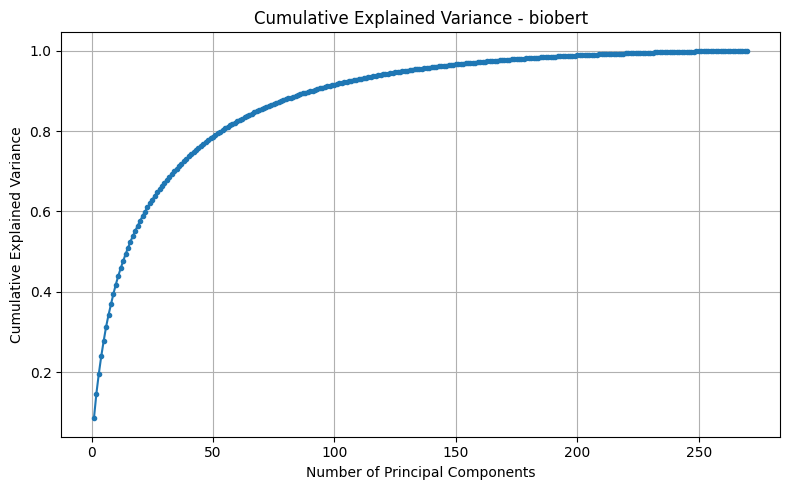

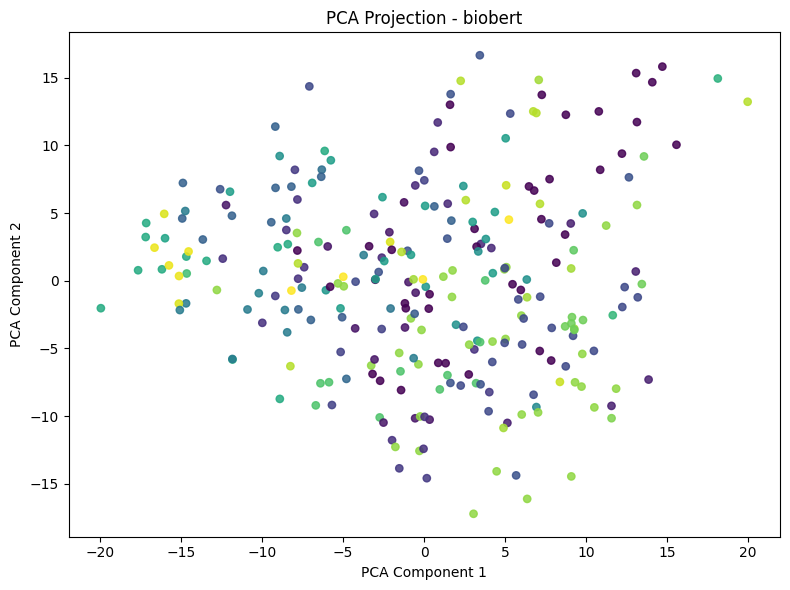

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


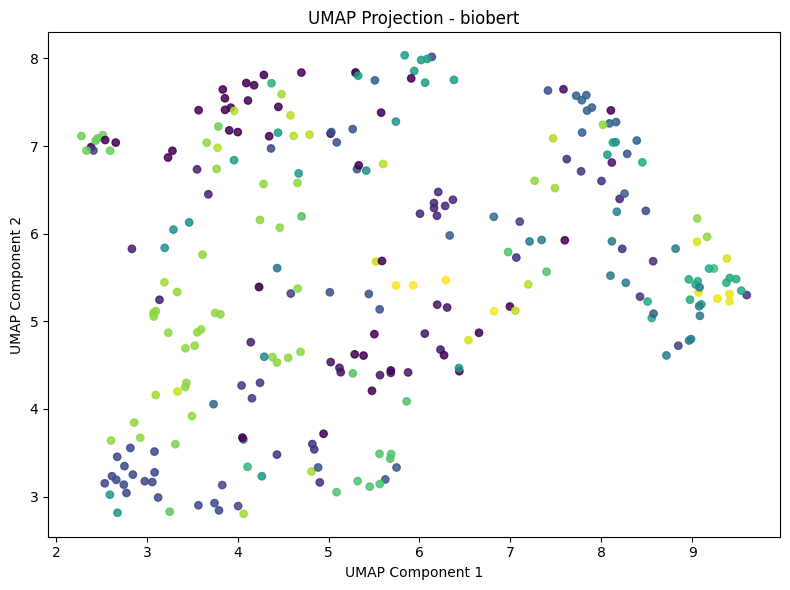

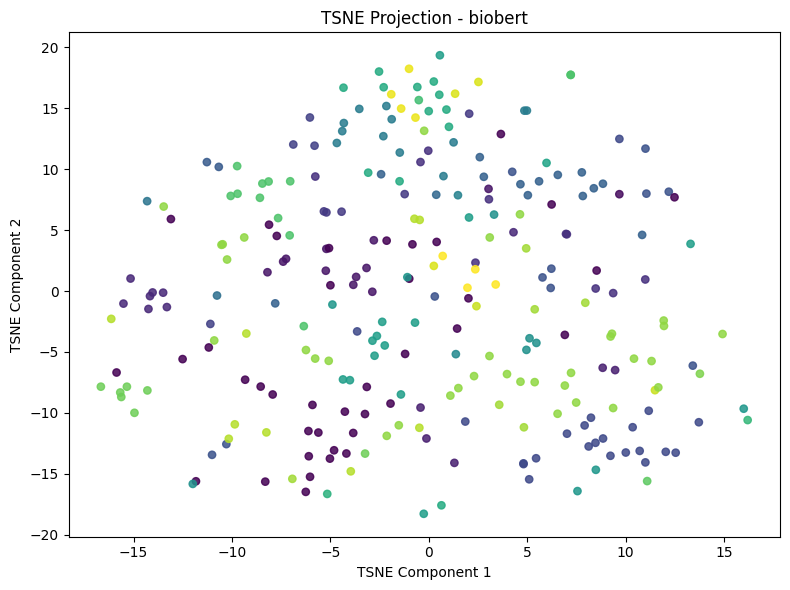


Processing: cookbert
Embedding shape: (270, 768)


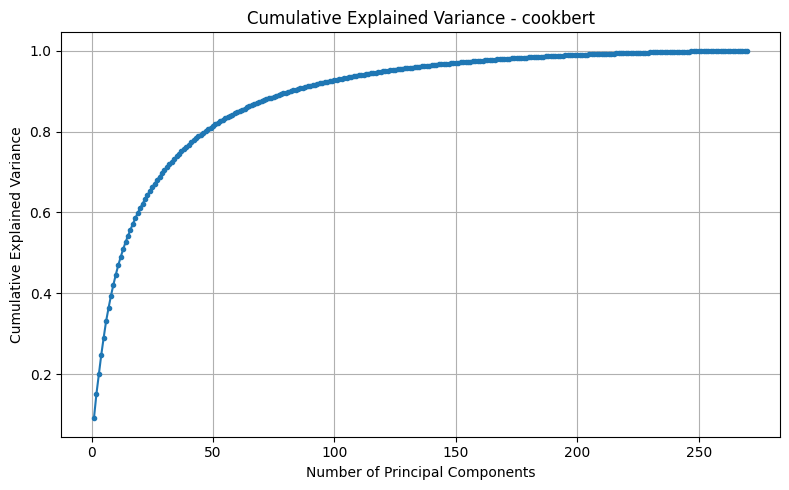

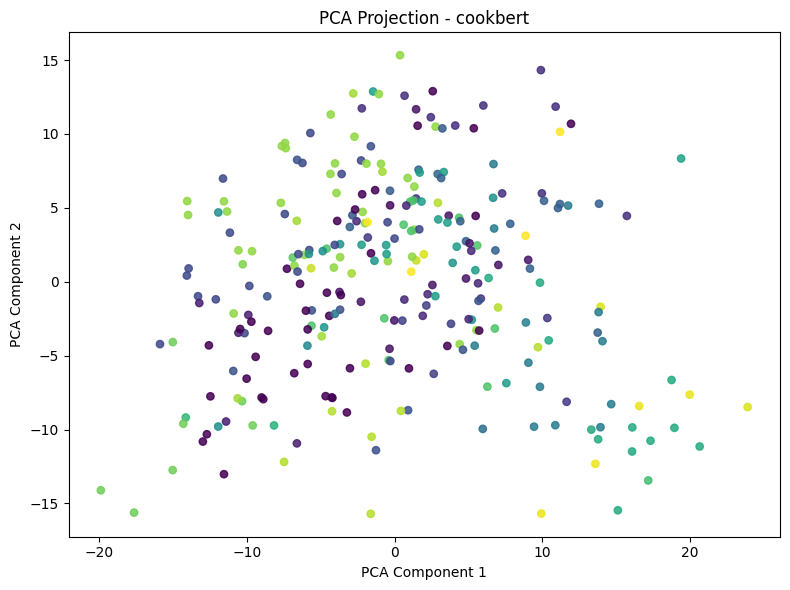

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


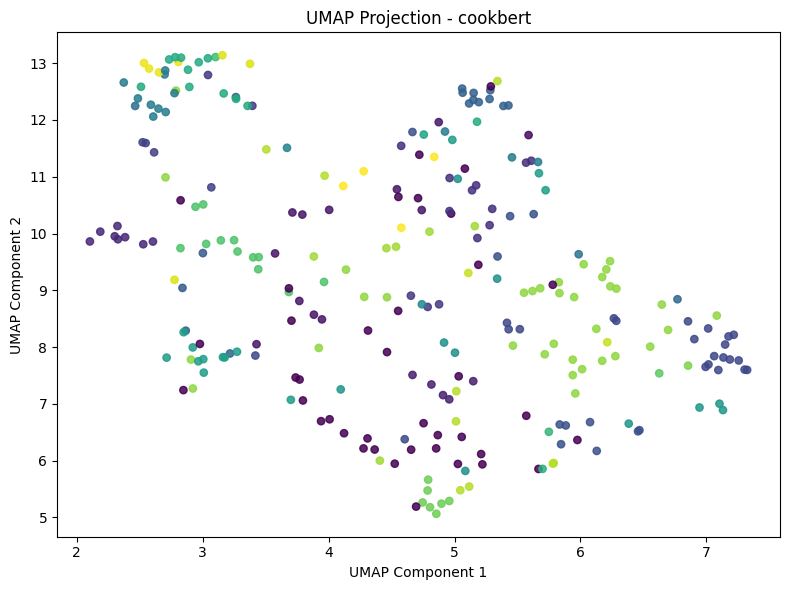

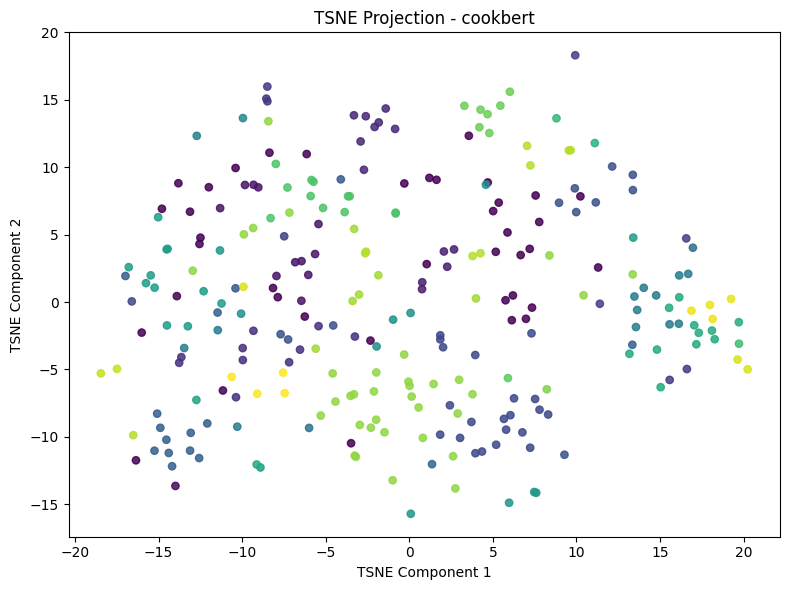


Processing: doc2vec
Embedding shape: (270, 300)


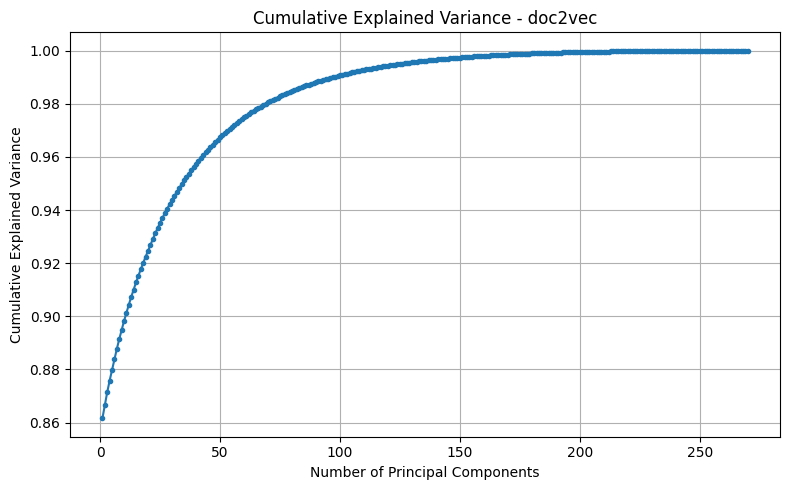

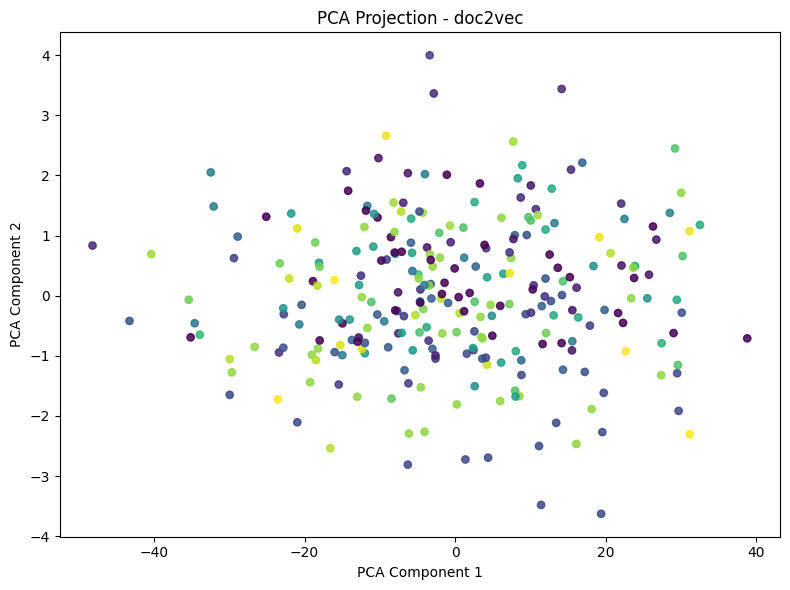

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


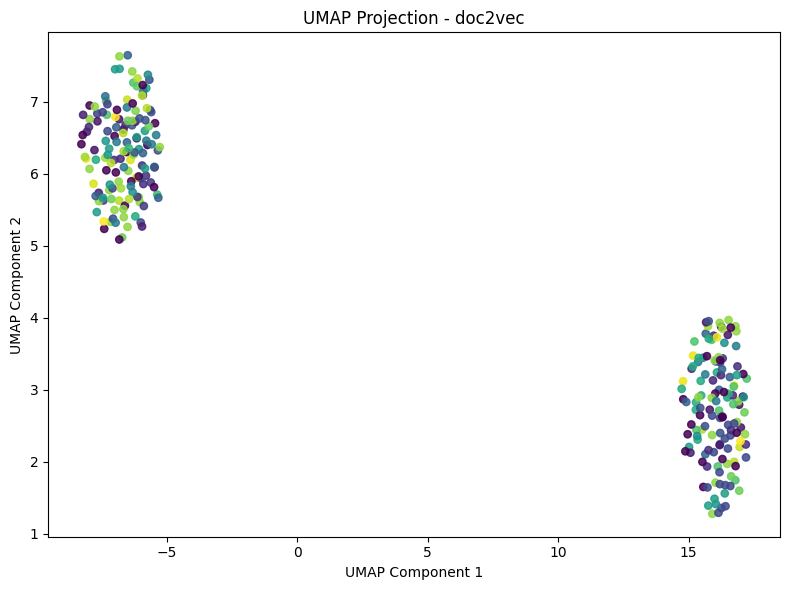

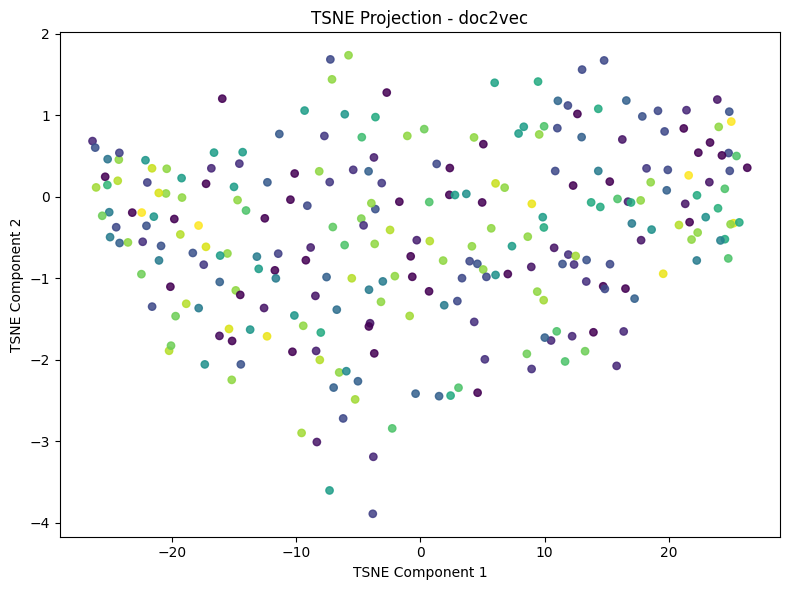


Processing: foodbert
Embedding shape: (270, 768)


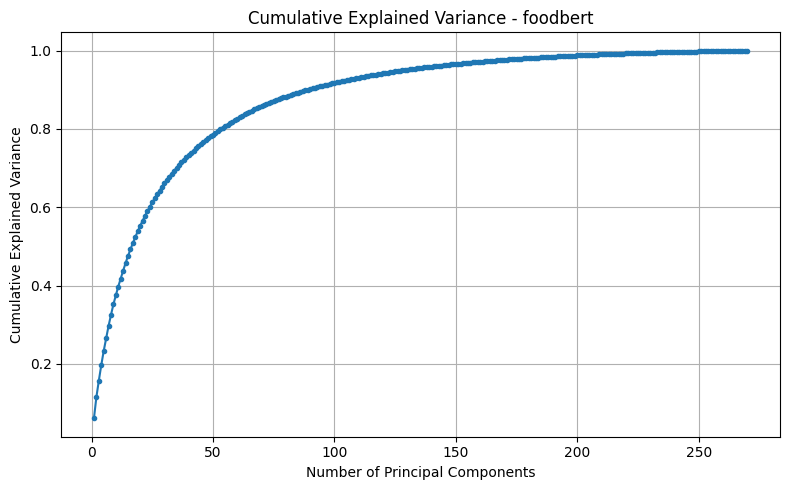

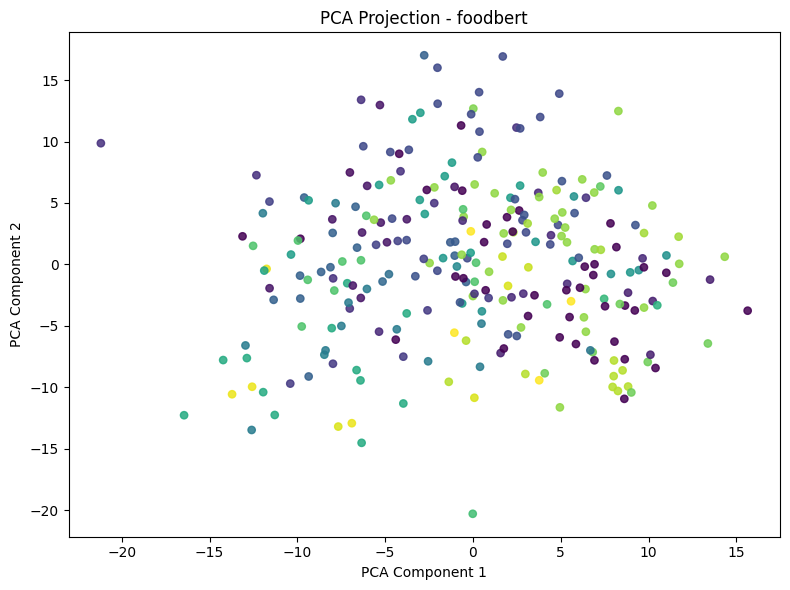

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


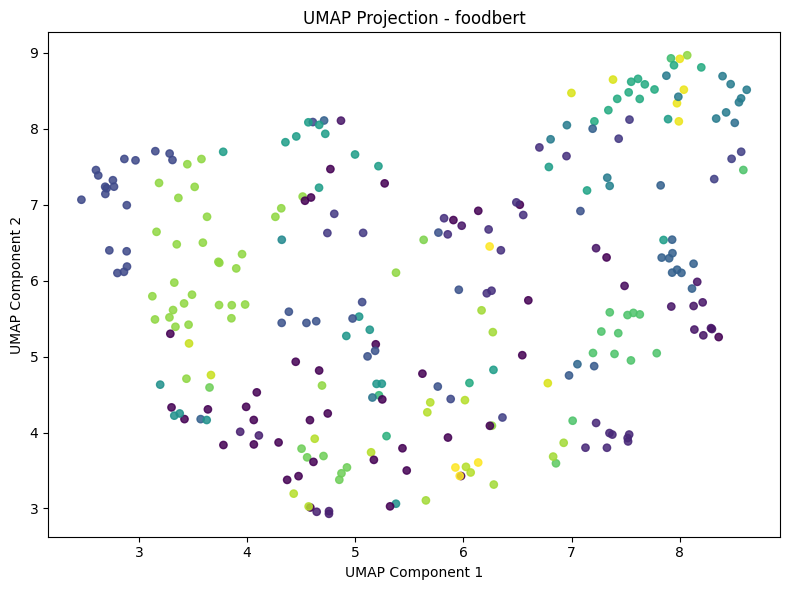

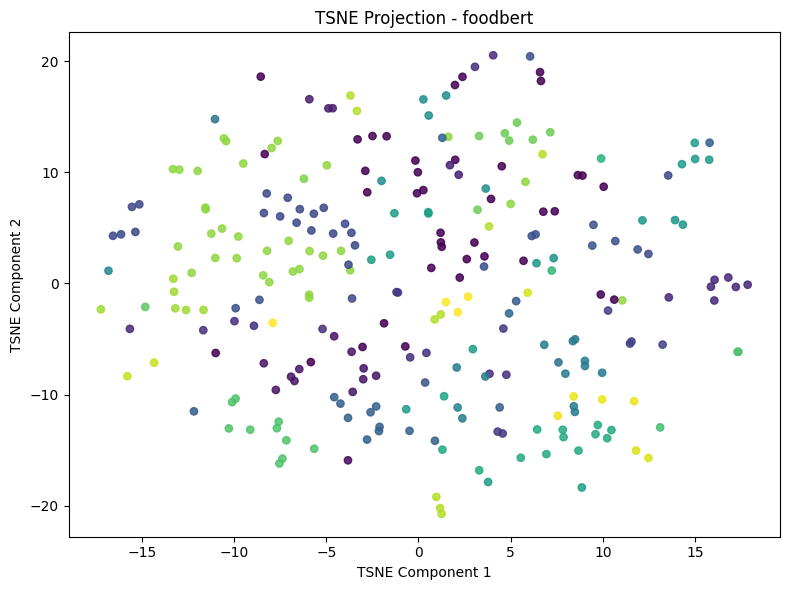


Processing: pubmedbert
Embedding shape: (270, 768)


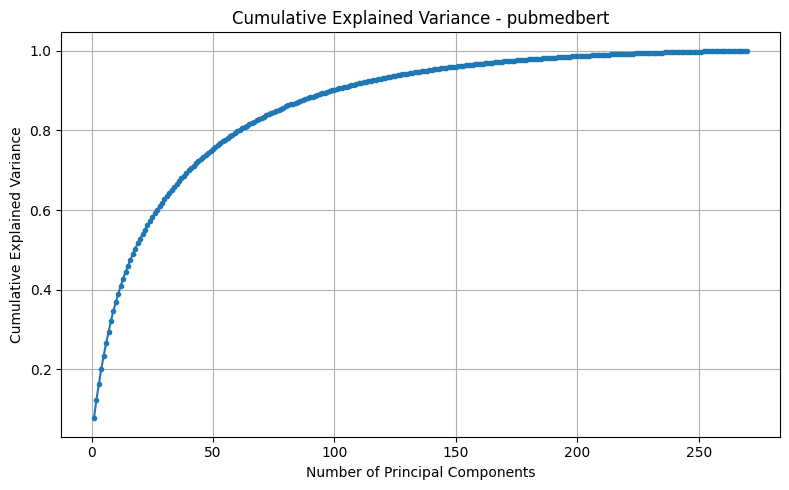

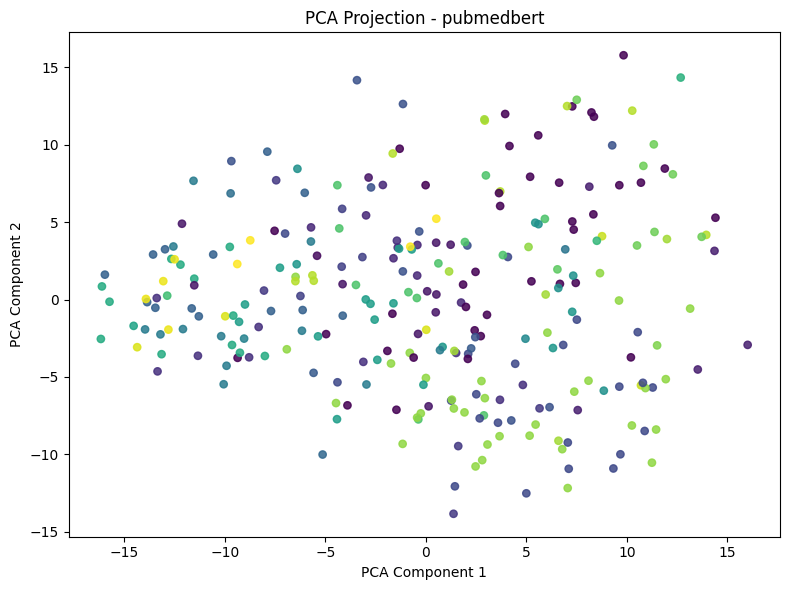

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


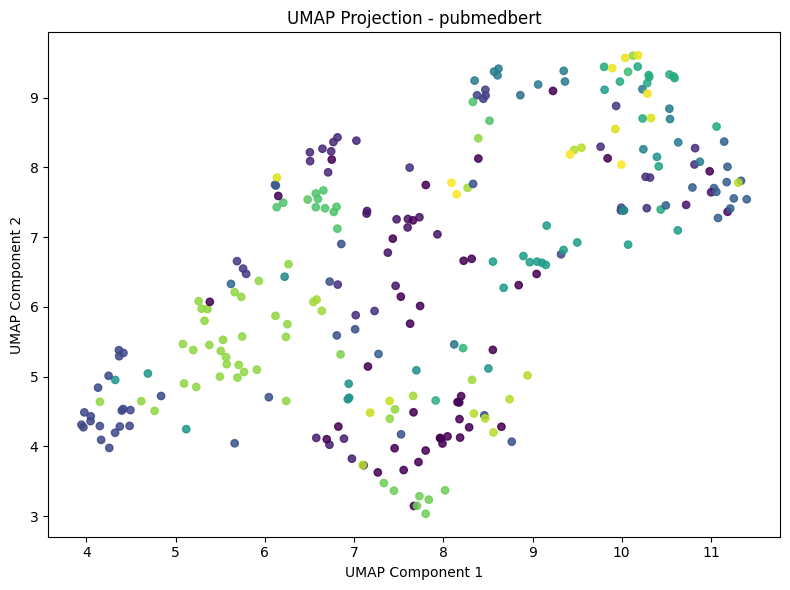

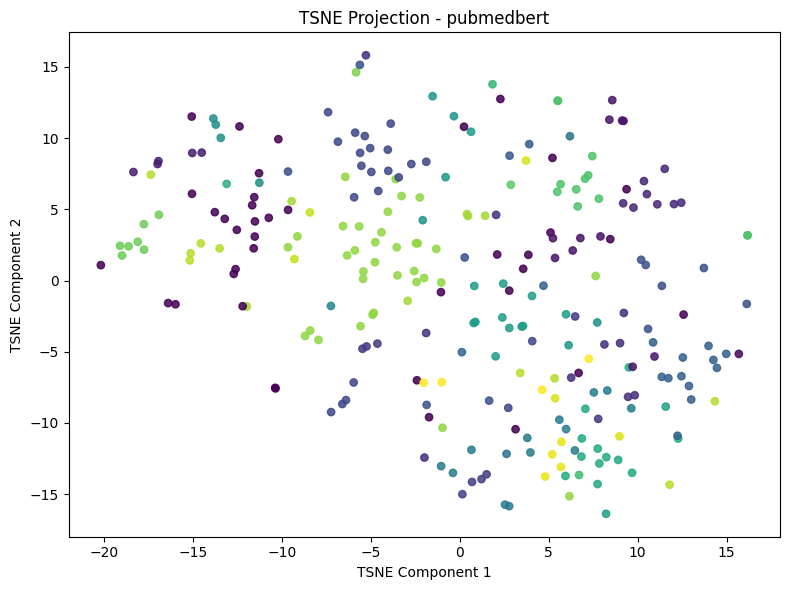


Processing: recipebert
Embedding shape: (270, 768)


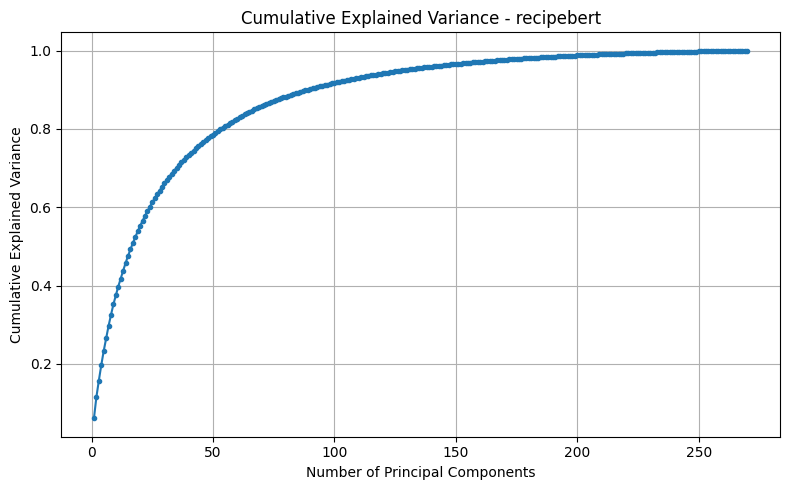

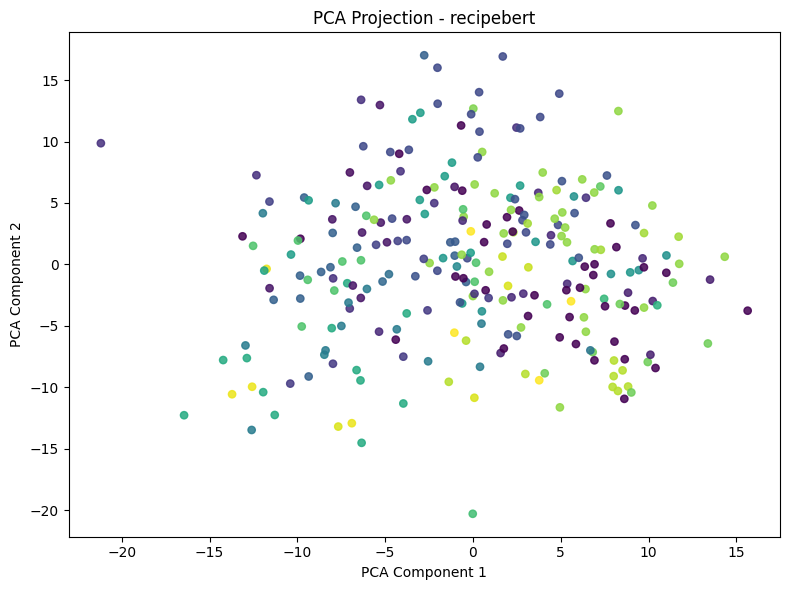

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


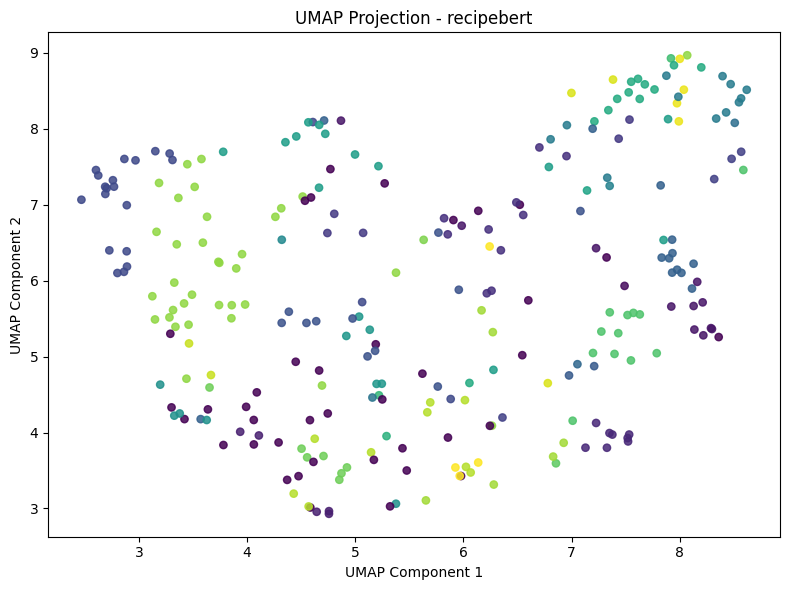

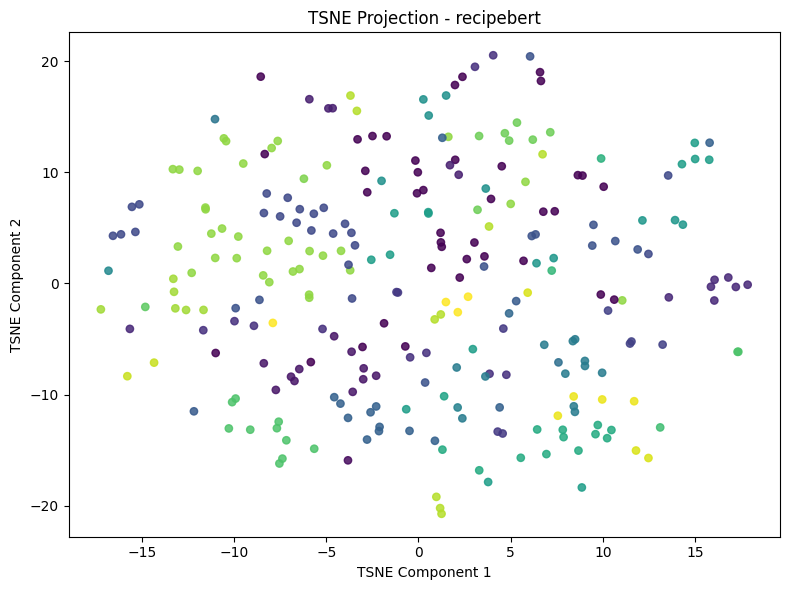


Processing: sbert
Embedding shape: (270, 768)


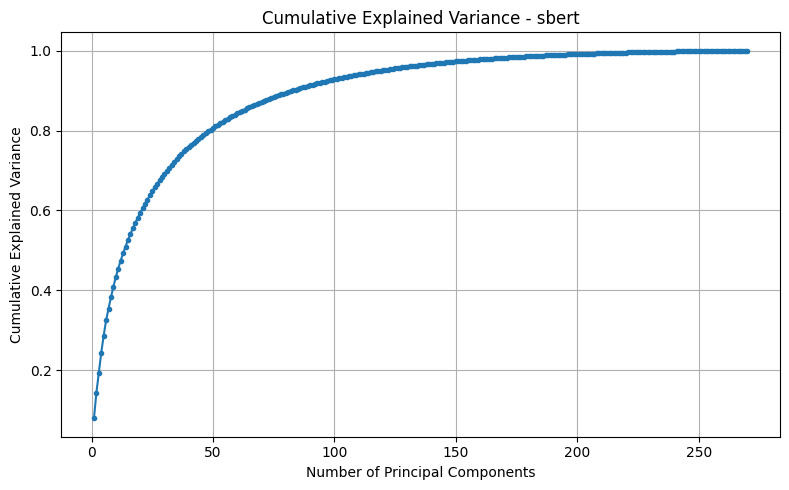

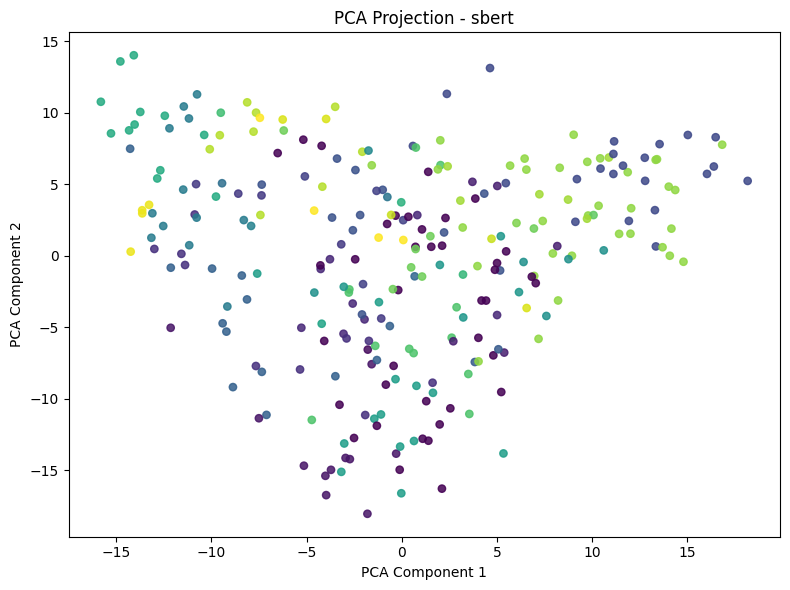

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


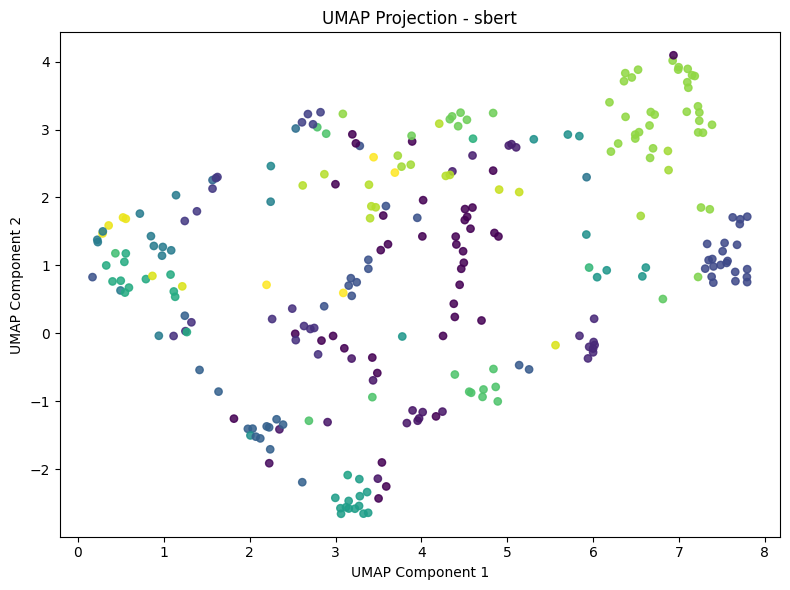

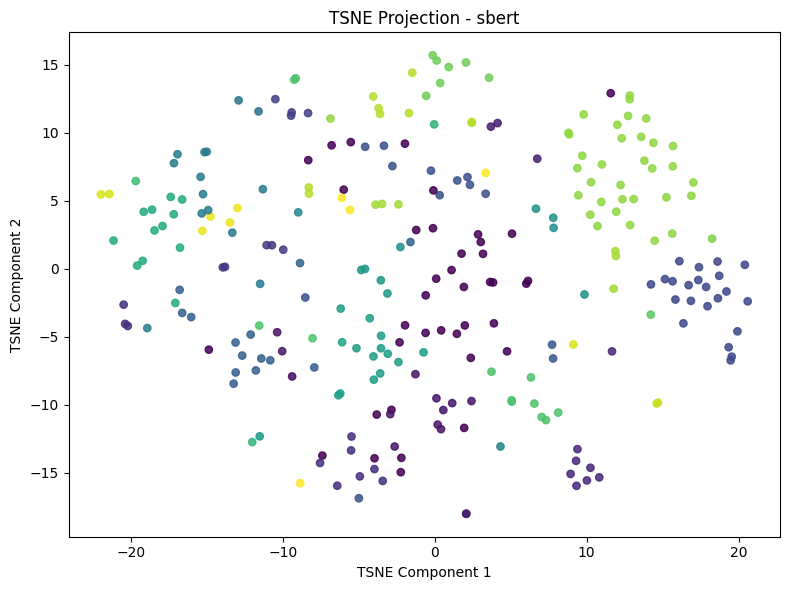


Done.
Processed models: ['biobert', 'cookbert', 'doc2vec', 'foodbert', 'pubmedbert', 'recipebert', 'sbert']
Skipped models: []
Plots saved in: /kaggle/working/embedding_visualizations


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# UMAP
UMAP_AVAILABLE = True
try:
    import umap
except Exception as e:
    UMAP_AVAILABLE = False
    print("UMAP import failed. UMAP plots will be skipped.")
    print("Reason:", e)


# =========================================================
# 1. PATHS
# =========================================================
BASE_DIR = "/kaggle/working"
MANUAL_FILE = "/kaggle/input/datasets/harshvishwakarma23/recipe-updates/protocol_manual_classification_updated.csv"
OUTPUT_DIR = os.path.join(BASE_DIR, "embedding_visualizations")

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================================
# 2. LOAD UPDATED MANUAL GROUND TRUTH
# =========================================================
manual_df = pd.read_csv(MANUAL_FILE)
manual_df.columns = manual_df.columns.str.strip()
manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()
manual_df["manual_label"] = manual_df["REMARK"].astype("category").cat.codes

word_to_label = dict(zip(manual_df["Word"], manual_df["manual_label"]))

print("Manual file loaded successfully.")
print("Total words:", len(manual_df))
print("Unique manual clusters:", manual_df["REMARK"].nunique())


# =========================================================
# 3. HELPERS
# =========================================================
def find_protocol_file(model_name):
    candidate = os.path.join(BASE_DIR, f"protocols_with_{model_name}_clusters.csv")
    if os.path.exists(candidate):
        return candidate

    # fallback for generic/sbert style naming
    if model_name == "sbert":
        candidate2 = os.path.join(BASE_DIR, "protocols_with_clusters.csv")
        if os.path.exists(candidate2):
            return candidate2

    return None


def get_words_in_embedding_order(model_name, n_rows):
    protocol_file = find_protocol_file(model_name)

    if protocol_file is not None:
        df = pd.read_csv(protocol_file)
        df.columns = df.columns.str.strip()

        word_col = None
        for col in ["Word", "word", "token", "verb"]:
            if col in df.columns:
                word_col = col
                break

        if word_col is None:
            raise ValueError(f"No word column found in {protocol_file}")

        words = df[word_col].astype(str).str.strip().str.lower().tolist()

        if len(words) != n_rows:
            raise ValueError(
                f"Mismatch for {model_name}: embeddings rows = {n_rows}, "
                f"words in protocol file = {len(words)}"
            )

        return words

    # fallback to manual file order
    words = manual_df["Word"].tolist()
    if len(words) != n_rows:
        raise ValueError(
            f"Fallback manual order failed for {model_name}: embeddings rows = {n_rows}, "
            f"manual rows = {len(words)}"
        )
    return words


def get_labels_from_words(words):
    missing = [w for w in words if w not in word_to_label]
    if missing:
        raise ValueError(f"These words are missing from manual file: {missing[:10]}")
    return np.array([word_to_label[w] for w in words])


def load_embeddings_safely(emb_path, model_name):
    file_size = os.path.getsize(emb_path)

    if file_size == 0:
        print(f"Skipping {model_name}: file is empty.")
        return None

    try:
        X = np.load(emb_path)
        return X
    except Exception as e:
        print(f"Skipping {model_name}: could not load embeddings. Reason: {e}")
        return None


def plot_cumulative_explained_variance(X, model_name):
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=3)
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title(f"Cumulative Explained Variance - {model_name}")
    plt.grid(True)
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_cumulative_explained_variance.png")
    plt.savefig(save_path, dpi=300)
    plt.show()


def plot_2d_scatter(Z, labels, model_name, method_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=28, alpha=0.85)
    plt.title(f"{method_name} Projection - {model_name}")
    plt.xlabel(f"{method_name} Component 1")
    plt.ylabel(f"{method_name} Component 2")
    plt.tight_layout()

    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_{method_name.lower()}_2d.png")
    plt.savefig(save_path, dpi=300)
    plt.show()


def run_pca_umap_tsne(X, labels, model_name):
    X_scaled = StandardScaler().fit_transform(X)

    # PCA
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
    plot_2d_scatter(X_pca, labels, model_name, "PCA")

    # UMAP
    if UMAP_AVAILABLE:
        X_umap = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            metric="cosine",
            random_state=42
        ).fit_transform(X_scaled)
        plot_2d_scatter(X_umap, labels, model_name, "UMAP")
    else:
        print(f"Skipping UMAP for {model_name} because UMAP is not available.")

    # t-SNE
    X_tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X_scaled)
    plot_2d_scatter(X_tsne, labels, model_name, "TSNE")


# =========================================================
# 4. FIND ALL EMBEDDING FILES
# =========================================================
embedding_files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith("_embeddings.npy")])

print("\nEmbedding files found:")
for f in embedding_files:
    print("-", f)


# =========================================================
# 5. RUN FOR ALL EMBEDDINGS
# =========================================================
processed_models = []
skipped_models = []

for emb_file in embedding_files:
    model_name = emb_file.replace("_embeddings.npy", "")
    emb_path = os.path.join(BASE_DIR, emb_file)

    print("\n==============================")
    print(f"Processing: {model_name}")
    print("==============================")

    X = load_embeddings_safely(emb_path, model_name)

    if X is None:
        skipped_models.append(model_name)
        continue

    if not isinstance(X, np.ndarray):
        print(f"Skipping {model_name}: loaded object is not a numpy array.")
        skipped_models.append(model_name)
        continue

    if X.ndim != 2:
        print(f"Skipping {model_name}: embeddings must be 2D, got shape {X.shape}")
        skipped_models.append(model_name)
        continue

    print("Embedding shape:", X.shape)

    try:
        words_in_order = get_words_in_embedding_order(model_name, X.shape[0])
        labels = get_labels_from_words(words_in_order)

        plot_cumulative_explained_variance(X, model_name)
        run_pca_umap_tsne(X, labels, model_name)

        processed_models.append(model_name)

    except Exception as e:
        print(f"Skipping {model_name} during plotting/alignment: {e}")
        skipped_models.append(model_name)

print("\nDone.")
print("Processed models:", processed_models)
print("Skipped models:", skipped_models)
print("Plots saved in:", OUTPUT_DIR)

Manual labels loaded.
Total words: 270
Embedding shape: (270, 768)


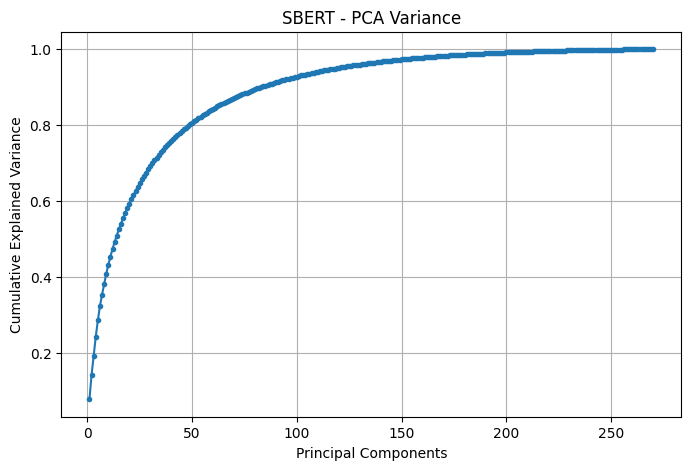

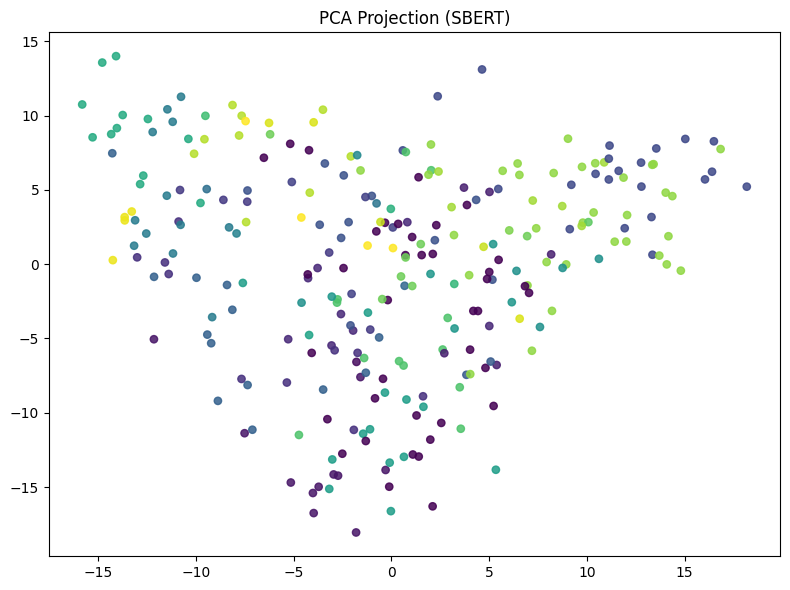

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


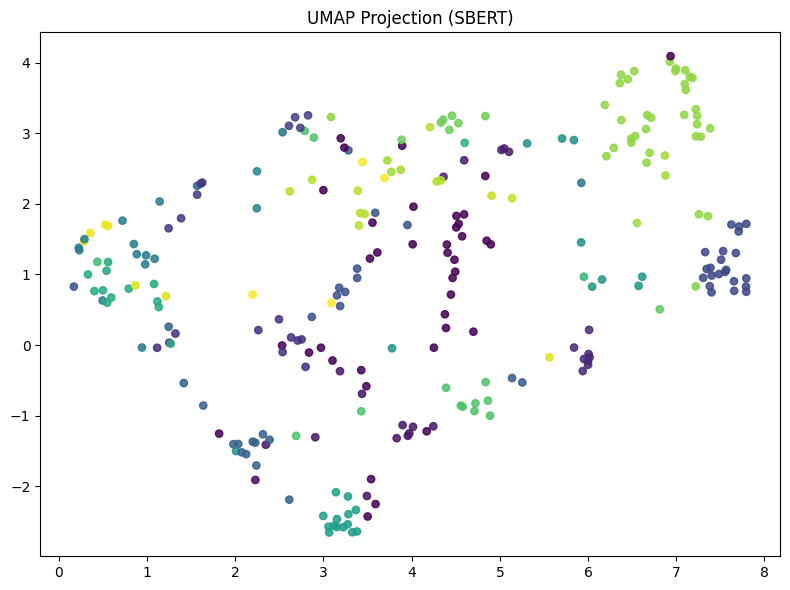

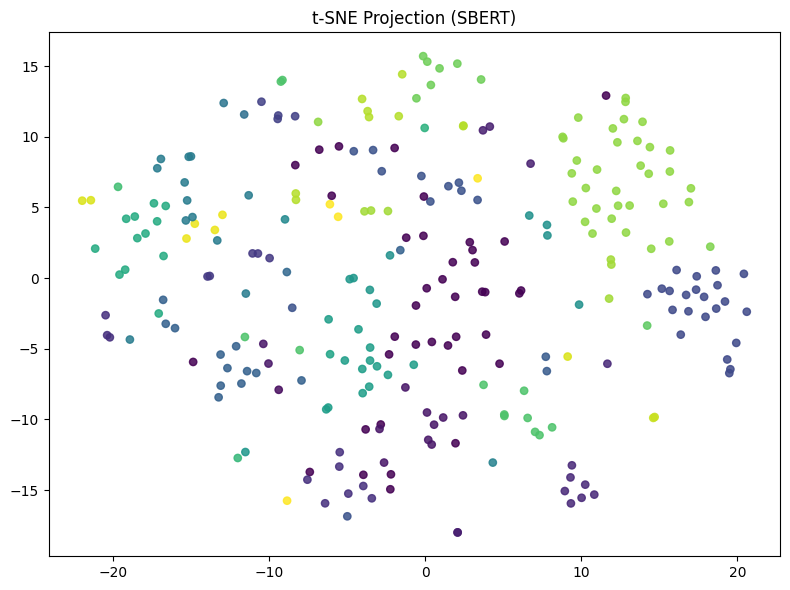

✅ SBERT visualization completed
Saved in: /kaggle/working/sbert_visualizations


In [11]:
# =========================
# SBERT Embedding Visualization
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# UMAP
UMAP_AVAILABLE = True
try:
    import umap
except Exception as e:
    UMAP_AVAILABLE = False
    print("UMAP import failed. UMAP plots will be skipped.")
    print("Reason:", e)


# =========================================================
# 1. PATHS
# =========================================================
BASE_DIR = "/kaggle/working"

# 🔥 SBERT embeddings file
EMB_PATH = os.path.join(BASE_DIR, "sbert_embeddings.npy")

# SBERT protocol file (generated earlier)
PROTOCOL_FILE = os.path.join(BASE_DIR, "protocols_with_sbert_clusters.csv")

# Manual labels
MANUAL_FILE = "/kaggle/input/datasets/harshvishwakarma23/recipe-updates/protocol_manual_classification_updated.csv"

OUTPUT_DIR = os.path.join(BASE_DIR, "sbert_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================================================
# 2. LOAD DATA
# =========================================================
manual_df = pd.read_csv(MANUAL_FILE)
manual_df.columns = manual_df.columns.str.strip()
manual_df["Word"] = manual_df["Word"].astype(str).str.strip().str.lower()
manual_df["REMARK"] = manual_df["REMARK"].astype(str).str.strip().str.lower()
manual_df["manual_label"] = manual_df["REMARK"].astype("category").cat.codes

word_to_label = dict(zip(manual_df["Word"], manual_df["manual_label"]))

print("Manual labels loaded.")
print("Total words:", len(manual_df))


# =========================================================
# 3. LOAD EMBEDDINGS
# =========================================================
X = np.load(EMB_PATH)

if X.ndim != 2:
    raise ValueError(f"Embeddings must be 2D, got shape {X.shape}")

print("Embedding shape:", X.shape)


# =========================================================
# 4. LOAD WORD ORDER FROM SBERT FILE
# =========================================================
df_protocol = pd.read_csv(PROTOCOL_FILE)
df_protocol.columns = df_protocol.columns.str.strip()

word_col = None
for col in ["Word", "word", "token", "verb"]:
    if col in df_protocol.columns:
        word_col = col
        break

if word_col is None:
    raise ValueError("No word column found in SBERT protocol file.")

words = df_protocol[word_col].astype(str).str.strip().str.lower().tolist()

if len(words) != X.shape[0]:
    raise ValueError("Mismatch between embeddings and words.")


# =========================================================
# 5. MAP LABELS
# =========================================================
missing = [w for w in words if w not in word_to_label]
if missing:
    raise ValueError(f"Missing words in manual labels: {missing[:10]}")

labels = np.array([word_to_label[w] for w in words])


# =========================================================
# 6. PLOT FUNCTIONS
# =========================================================
def plot_cumulative_variance(X):
    X_scaled = StandardScaler().fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", markersize=3)
    plt.xlabel("Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("SBERT - PCA Variance")
    plt.grid(True)

    plt.savefig(os.path.join(OUTPUT_DIR, "sbert_pca_variance.png"), dpi=300)
    plt.show()


def plot_2d(Z, title, filename):
    plt.figure(figsize=(8, 6))
    plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=28, alpha=0.85)
    plt.title(title)
    plt.tight_layout()

    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.show()


# =========================================================
# 7. RUN VISUALIZATION
# =========================================================
X_scaled = StandardScaler().fit_transform(X)

# PCA variance
plot_cumulative_variance(X)

# PCA 2D
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plot_2d(X_pca, "PCA Projection (SBERT)", "sbert_pca_2d.png")

# UMAP
if UMAP_AVAILABLE:
    X_umap = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    ).fit_transform(X_scaled)

    plot_2d(X_umap, "UMAP Projection (SBERT)", "sbert_umap_2d.png")
else:
    print("UMAP skipped.")

# t-SNE
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
).fit_transform(X_scaled)

plot_2d(X_tsne, "t-SNE Projection (SBERT)", "sbert_tsne_2d.png")


print("✅ SBERT visualization completed")
print("Saved in:", OUTPUT_DIR)

In [12]:
# =========================
# SBERT Clustering Pipeline (Improved Dendrogram)
# =========================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import umap

# -------------------------
# Reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# -------------------------
# Configuration
# -------------------------
DATA_FILE = "/kaggle/input/protocol-dataset/evaluation_results_with_alignment.csv"
TEXT_COL = "merged_text"
LABEL_COL = "word"
NUM_CLUSTERS = 30
BATCH_SIZE = 32

MODEL_NAME = "all-mpnet-base-v2"

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(DATA_FILE).fillna("")
df[TEXT_COL] = df[TEXT_COL].astype(str)
df["Word"] = df[LABEL_COL].astype(str)

texts = df[TEXT_COL].tolist()

# -------------------------
# SBERT Embeddings
# -------------------------
model = SentenceTransformer(MODEL_NAME, device=DEVICE)

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

np.save("sbert_embeddings.npy", embeddings)

# -------------------------
# Cosine similarity
# -------------------------
sim = cosine_similarity(embeddings)

pd.DataFrame(sim, index=df["Word"], columns=df["Word"]) \
  .to_csv("sbert_cosine_similarity.csv")

# -------------------------
# Hierarchical clustering
# -------------------------
Z = linkage(squareform(1 - sim, checks=False), method="average")

# 🔥 Improved Dendrogram (VERTICAL LABELS)
plt.figure(figsize=(12, 40))  # BIG height for readability

dendrogram(
    Z,
    labels=df["Word"].values,
    orientation='right',      # 🔥 vertical layout (labels on Y-axis)
    leaf_font_size=7          # adjust if still crowded
)

plt.title("Hierarchical Clustering (SBERT)", fontsize=14)
plt.xlabel("Distance", fontsize=12)
plt.ylabel("Protocols", fontsize=12)

plt.tight_layout()
plt.savefig("sbert_dendrogram_vertical.png", dpi=300)
plt.close()

# -------------------------
# Cut clusters
# -------------------------
df["sbert_cluster"] = fcluster(Z, t=NUM_CLUSTERS, criterion="maxclust")
df.to_csv("protocols_with_sbert_clusters.csv", index=False)

# -------------------------
# UMAP Visualization
# -------------------------
um = umap.UMAP(n_components=2, random_state=SEED)
proj = um.fit_transform(embeddings)

df["umap_x"], df["umap_y"] = proj[:,0], proj[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(
    x="umap_x",
    y="umap_y",
    hue="sbert_cluster",
    data=df,
    palette="tab20",
    legend=False
)

plt.title("UMAP (SBERT)")
plt.tight_layout()
plt.savefig("sbert_umap.png", dpi=300)
plt.close()

# -------------------------
# Silhouette Score
# -------------------------
score = silhouette_score(embeddings, df["sbert_cluster"], metric="cosine")
print("Silhouette Score:", score)

# -------------------------
# Save clusters
# -------------------------
os.makedirs("sbert_clusters", exist_ok=True)

for cid, g in df.groupby("sbert_cluster"):
    g.to_csv(f"sbert_clusters/cluster_{cid}.csv", index=False)

print("✅ SBERT pipeline completed")

Device: cuda


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score: 0.16548559
✅ SBERT pipeline completed


In [13]:
!zip -r all_results.zip /kaggle/working


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/sbert_dendrogram.png (deflated 20%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 82%)
  adding: kaggle/working/protocols_with_biobert_clusters.csv (deflated 74%)
  adding: kaggle/working/doc2vec_clusters/ (stored 0%)
  adding: kaggle/working/doc2vec_clusters/cluster_23.csv (deflated 45%)
  adding: kaggle/working/doc2vec_clusters/cluster_21.csv (deflated 46%)
  adding: kaggle/working/doc2vec_clusters/cluster_10.csv (deflated 47%)
  adding: kaggle/working/doc2vec_clusters/cluster_30.csv (deflated 48%)
  adding: kaggle/working/doc2vec_clusters/cluster_1.csv (deflated 70%)
  adding: kaggle/working/doc2vec_clusters/cluster_19.csv (deflated 45%)
  adding: kaggle/working/doc2vec_clusters/cluster_7.csv (deflated 46%)
  adding: kaggle/working/doc2vec_clusters/cluster_16.csv (deflated 45%)
  adding: kaggle/working/doc2vec_clusters/cluster_25.c